In [9]:
import pandas as pd

scores_path = "../sources/generation_details/retext_evolution/full_scores_langfuse.csv"
df_scores = pd.read_csv(scores_path, sep=",", quotechar='"')

df_scores.drop(columns=['id', 'traceId', 'sessionId', 'datasetRunId', 'source',
       'stringValue', 'comment', 'metadata',
       'observationId', 'traceName', 'userId', 'traceTags', 'environment',
       'authorUserName'], inplace=True)

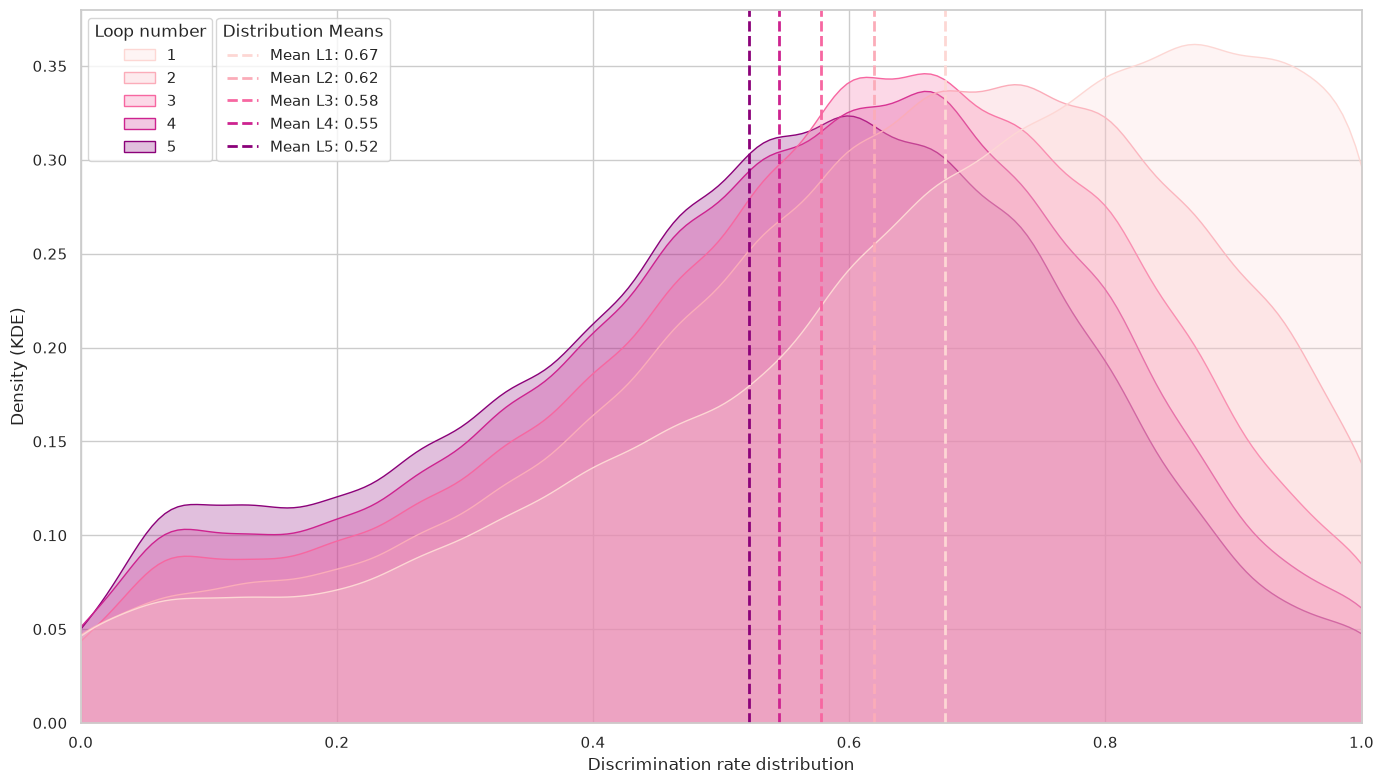

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df_scores["value"] = pd.to_numeric(df_scores["value"], errors="coerce")

target_scores = [f"error_rate_lap_{i}" for i in range(5)]
df_laps = df_scores[df_scores["name"].isin(target_scores)].copy()

df_laps = df_laps.sort_values(by="name")
labels_mapping = {f"error_rate_lap_{i}": f"{i+1}" for i in range(5)}
df_laps["Loop number"] = df_laps["name"].map(labels_mapping)
display_order = [labels_mapping[score] for score in target_scores]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

# 1. Définition de la palette
palette_name = "RdPu"
colors = sns.color_palette(palette_name, len(display_order))

# 2. Tracé du KDE (génère la légende Seaborn par défaut en haut à droite)
# On force sa position pour être sûr de ses coordonnées
sns.kdeplot(
    data=df_laps,
    x="value",
    hue="Loop number",
    hue_order=display_order,
    palette=palette_name,
    fill=True,
    cut=0,
    ax=ax,
)

# On récupère et on positionne explicitement la légende Seaborn tout à fait à droite
leg_kde = ax.get_legend()
leg_kde.set_bbox_to_anchor((0.0, 1.0))  # Coin supérieur droit à la limite du graphique
leg_kde.set_loc("upper left")

# 3. Calcul et ajout des lignes verticales pour chaque moyenne
for i, loop in enumerate(display_order):
    loop_data = df_laps[df_laps["Loop number"] == loop]["value"]

    if not loop_data.dropna().empty:
        mean_value = loop_data.mean()

        ax.axvline(
            x=mean_value,
            color=colors[i],
            linestyle="--",
            linewidth=2,
            label=f"Mean L{loop}: {mean_value:.2f}",
        )

# 4. Création de la deuxième légende (Moyennes) placée juste à côté
# bbox_to_anchor=(0.83, 1.0) place cette légende légèrement décalée vers la gauche
leg_means = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.1, 1.0), 
    title="Distribution Means",
    frameon=True
)

# 5. On ré-ajoute la légende Seaborn
ax.add_artist(leg_kde)

plt.xlabel("Discrimination rate distribution", fontsize=12)
plt.ylabel("Density (KDE)", fontsize=12)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()